In [ ]:
import pandas as pd

# # 1. Load both Base Data Files
print("Loading Base File 1...")
df_base1 = pd.read_csv("PUDF1Q2019_tab-delimited\PUDF_base1_1q2019_tab.txt", sep='\t', dtype=str)

print("Loading Base File 2...")
df_base2 = pd.read_csv("PUDF1Q2019_tab-delimited\PUDF_base2_1q2019_tab.txt", sep='\t', dtype=str)

# 2. Stitch them together into one giant dataset
print("Merging files...")
df_raw = pd.concat([df_base1, df_base2], ignore_index=True)

# Strip any hidden whitespace from column names just to be safe
df_raw.columns = df_raw.columns.str.strip()

# 3. Extract only the columns needed for our two AI Tasks
columns_to_keep = [
    "RECORD_ID", "SEX_CODE", "PAT_AGE", "RACE", "ETHNICITY",
    "PAT_ZIP", "SOURCE_OF_ADMISSION", "PRINC_DIAG_CODE", 
    "EMERGENCY_DEPT_FLAG", "LENGTH_OF_STAY", "FIRST_PAYMENT_SRC", 
    "TOTAL_CHARGES"
]
df_vault = df_raw[columns_to_keep].copy()

# 4. Translate the codes into plain English using the DSHS Data Dictionary
print("Translating codes to English...")

race_mapping = {
    '1': 'American Indian/Eskimo/Aleut', 
    '2': 'Asian or Pacific Islander', 
    '3': 'Black', 
    '4': 'White', 
    '5': 'Other'
}
df_vault['RACE'] = df_vault['RACE'].map(race_mapping)

sex_mapping = {'M': 'Male', 'F': 'Female', 'U': 'Unknown'}
df_vault['SEX_CODE'] = df_vault['SEX_CODE'].map(sex_mapping)

payer_mapping = {
    '09': 'Self Pay',
    '12': 'Medicare Part A',
    '13': 'Medicare Part B',
    '14': 'Medicaid',
    '16': 'Workers Compensation',
    'CI': 'Commercial Insurance',
    'BL': 'Blue Cross/Blue Shield'
}
df_vault['FIRST_PAYMENT_SRC'] = df_vault['FIRST_PAYMENT_SRC'].map(payer_mapping).fillna('Other Insurance')

# 5. Convert numeric columns to actual numbers for the algorithm
df_vault['TOTAL_CHARGES'] = pd.to_numeric(df_vault['TOTAL_CHARGES'], errors='coerce')
df_vault['LENGTH_OF_STAY'] = pd.to_numeric(df_vault['LENGTH_OF_STAY'], errors='coerce') # <-- FIXED!

# Drop any rows that are missing critical data
df_vault = df_vault.dropna()

print(len(df_vault)) 

# 6. Take a 10,000 row random sample so your algorithm runs fast!
print("Sampling 10,000 random patients...")
df_vault_sample = df_vault.sample(n=10000, random_state=40)

print("\n--- Data Cleaning Complete! ---")
print("Here is a peek at your new Patient Vault:")
print(df_vault_sample.head())

# Save this clean version to run your Markov Blanket on!
df_vault_sample.to_csv("Cleaned_Patient_Vault.csv", index=False)
print("\nSaved successfully as 'Cleaned_Patient_Vault.csv'!")

Loading Base File 1...
Loading Base File 2...
Merging files...
Translating codes to English...
Sampling 10,000 random patients...

--- Data Cleaning Complete! ---
Here is a peek at your new Patient Vault:
           RECORD_ID SEX_CODE PAT_AGE   RACE ETHNICITY PAT_ZIP  \
123146  120190347530   Female      09  White         2   79928   
607423  120191857818  Unknown      17  White         2       `   
222654  120190662116     Male      19  White         2   79424   
602811  120191851669     Male      18  White         1   78102   
159563  120190459279   Female      13  White         2   79603   

       SOURCE_OF_ADMISSION PRINC_DIAG_CODE EMERGENCY_DEPT_FLAG  \
123146                   2          O34211                   N   
607423                   2           I6523                   N   
222654                   1           A4181                   Y   
602811                   1            I130                   Y   
159563                   1           I6521                   N   

 

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHAR

Loading the Patient Vault...
Discretizing continuous variables...
Running Causal Discovery (This will take a few seconds)...


  0%|          | 11/1000000 [00:00<19:57:41, 13.92it/s]



Clinical AI Allowed Data: ['TOTAL_CHARGES', 'SEX_CODE', 'EMERGENCY_DEPT_FLAG']
Billing AI Allowed Data:  ['SOURCE_OF_ADMISSION', 'LENGTH_OF_STAY', 'PAT_AGE', 'SEX_CODE', 'EMERGENCY_DEPT_FLAG']

Generating focused subgraph plots with arrows...


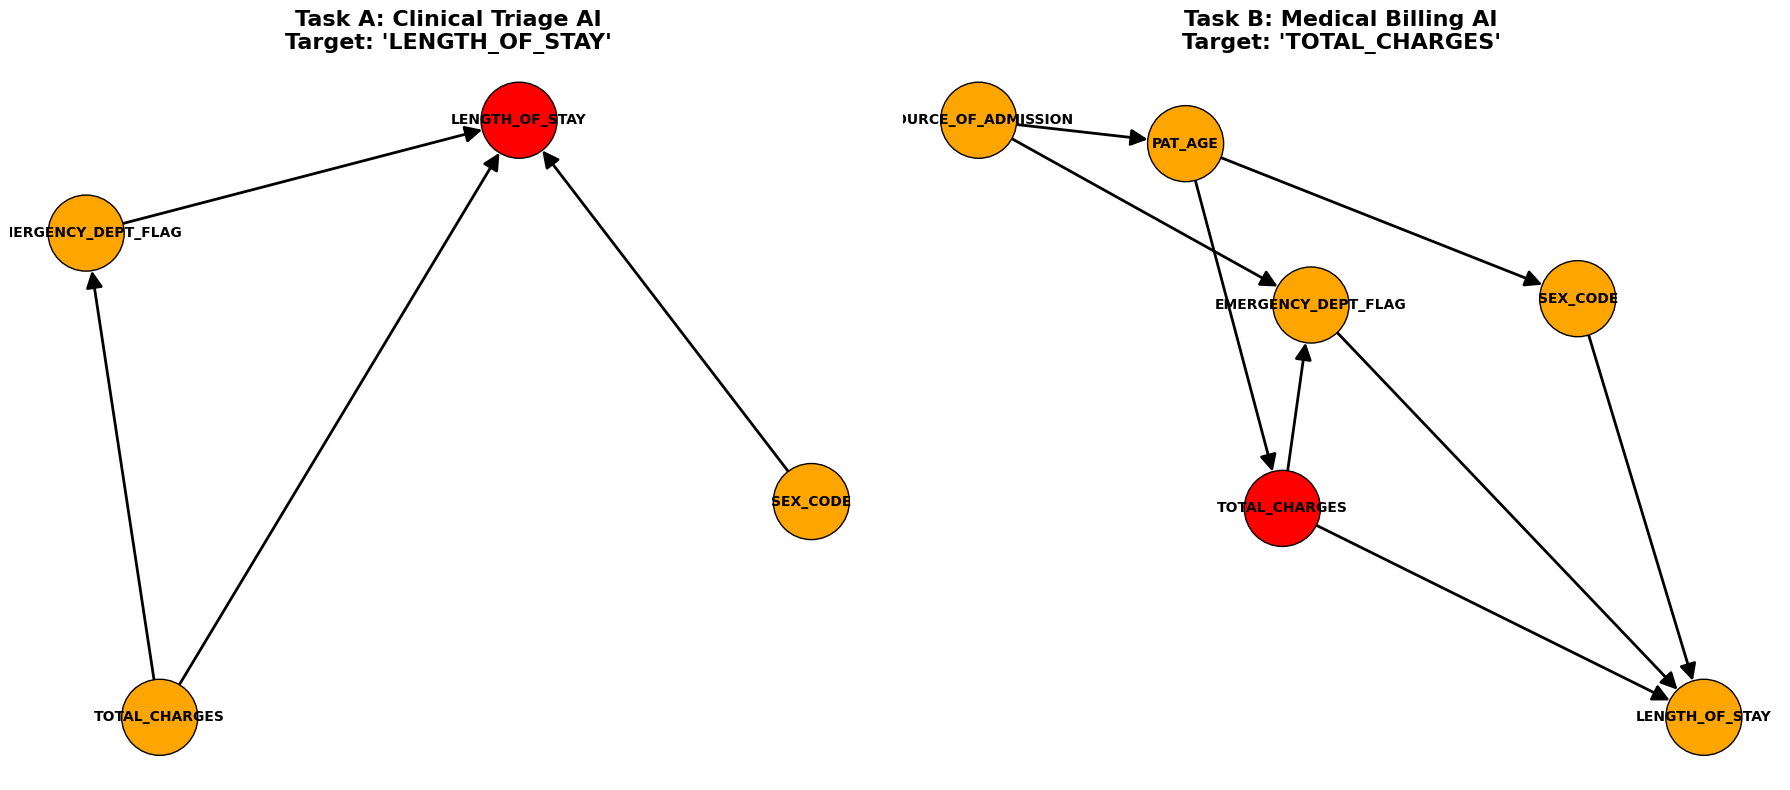

In [13]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. PREP THE DATA
# ==========================================
print("Loading the Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])

print("Discretizing continuous variables...")
df_vault['TOTAL_CHARGES'] = pd.qcut(df_vault['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_vault['LENGTH_OF_STAY'] = pd.qcut(df_vault['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Convert everything to strings so pgmpy knows it is discrete categorical data
df_vault = df_vault.astype(str)

# ==========================================
# 2. DO THE MATH (Creates 'bn')
# ==========================================
print("Running Causal Discovery (This will take a few seconds)...")
hc = HillClimbSearch(df_vault)

# FIXED: The new pgmpy 1.0 string for discrete BIC scoring is "bic-d"
best_model = hc.estimate(scoring_method="bic-d") 

bn = DiscreteBayesianNetwork(best_model.edges())

target_clinical = "LENGTH_OF_STAY"
mb_clinical = bn.get_markov_blanket(target_clinical)

target_financial = "TOTAL_CHARGES"
mb_financial = bn.get_markov_blanket(target_financial)

print(f"\nClinical AI Allowed Data: {mb_clinical}")
print(f"Billing AI Allowed Data:  {mb_financial}")

# ==========================================
# 3. DRAW THE FOCUSED MARKOV BLANKET GRAPHS (WITH VISIBLE ARROWS)
# ==========================================
print("\nGenerating focused subgraph plots with arrows...")
G = nx.DiGraph()
G.add_nodes_from(list(bn.nodes()))
G.add_edges_from(list(bn.edges()))

targets = {
    "Task A: Clinical Triage AI": (target_clinical, mb_clinical),
    "Task B: Medical Billing AI": (target_financial, mb_financial)
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (title, (target_node, mb_nodes)) in zip(axes, targets.items()):
    # 1. Create a focused Subgraph of ONLY the Target and its Markov Blanket
    focus_nodes = [target_node] + mb_nodes
    sub_G = G.subgraph(focus_nodes)
    
    # 2. Let NetworkX space them out nicely 
    pos = nx.spring_layout(sub_G, seed=42)
    
    # 3. Color the Target Red and the Markov Blanket Orange
    node_colors = ["red" if node == target_node else "orange" for node in sub_G.nodes()]

    # 4. Draw the nodes
    nx.draw_networkx_nodes(sub_G, pos, ax=ax, node_size=3000, node_color=node_colors, edgecolors="black")
    
    # 5. FIXED: Draw the edges, passing node_size so the arrows sit OUTSIDE the circles
    nx.draw_networkx_edges(
        sub_G, pos, ax=ax, 
        arrows=True, 
        arrowstyle="-|>", 
        arrowsize=25, 
        edge_color="black", 
        width=2,
        node_size=3000  # <--- THIS IS THE MAGIC FIX!
    )
    
    # 6. Add labels
    nx.draw_networkx_labels(sub_G, pos, ax=ax, font_size=10, font_weight="bold")
    
    ax.axis("off")
    ax.set_title(f"{title}\nTarget: '{target_node}'", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHARGES': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'SEX_CODE': 'C', 'PAT_AGE': 'C', 'RACE': 'C', 'ETHNICITY': 'C', 'PAT_ZIP': 'C', 'SOURCE_OF_ADMISSION': 'C', 'PRINC_DIAG_CODE': 'C', 'EMERGENCY_DEPT_FLAG': 'C', 'LENGTH_OF_STAY': 'C', 'FIRST_PAYMENT_SRC': 'C', 'TOTAL_CHAR

Loading the Patient Vault...
Discretizing continuous variables...
Running Causal Discovery (This will take a few seconds)...


  0%|          | 11/1000000 [00:00<18:41:49, 14.86it/s]



Clinical AI Allowed Data: ['TOTAL_CHARGES', 'SEX_CODE', 'EMERGENCY_DEPT_FLAG']
Billing AI Allowed Data:  ['SOURCE_OF_ADMISSION', 'LENGTH_OF_STAY', 'PAT_AGE', 'SEX_CODE', 'EMERGENCY_DEPT_FLAG']

Generating full network plots with visible arrows...


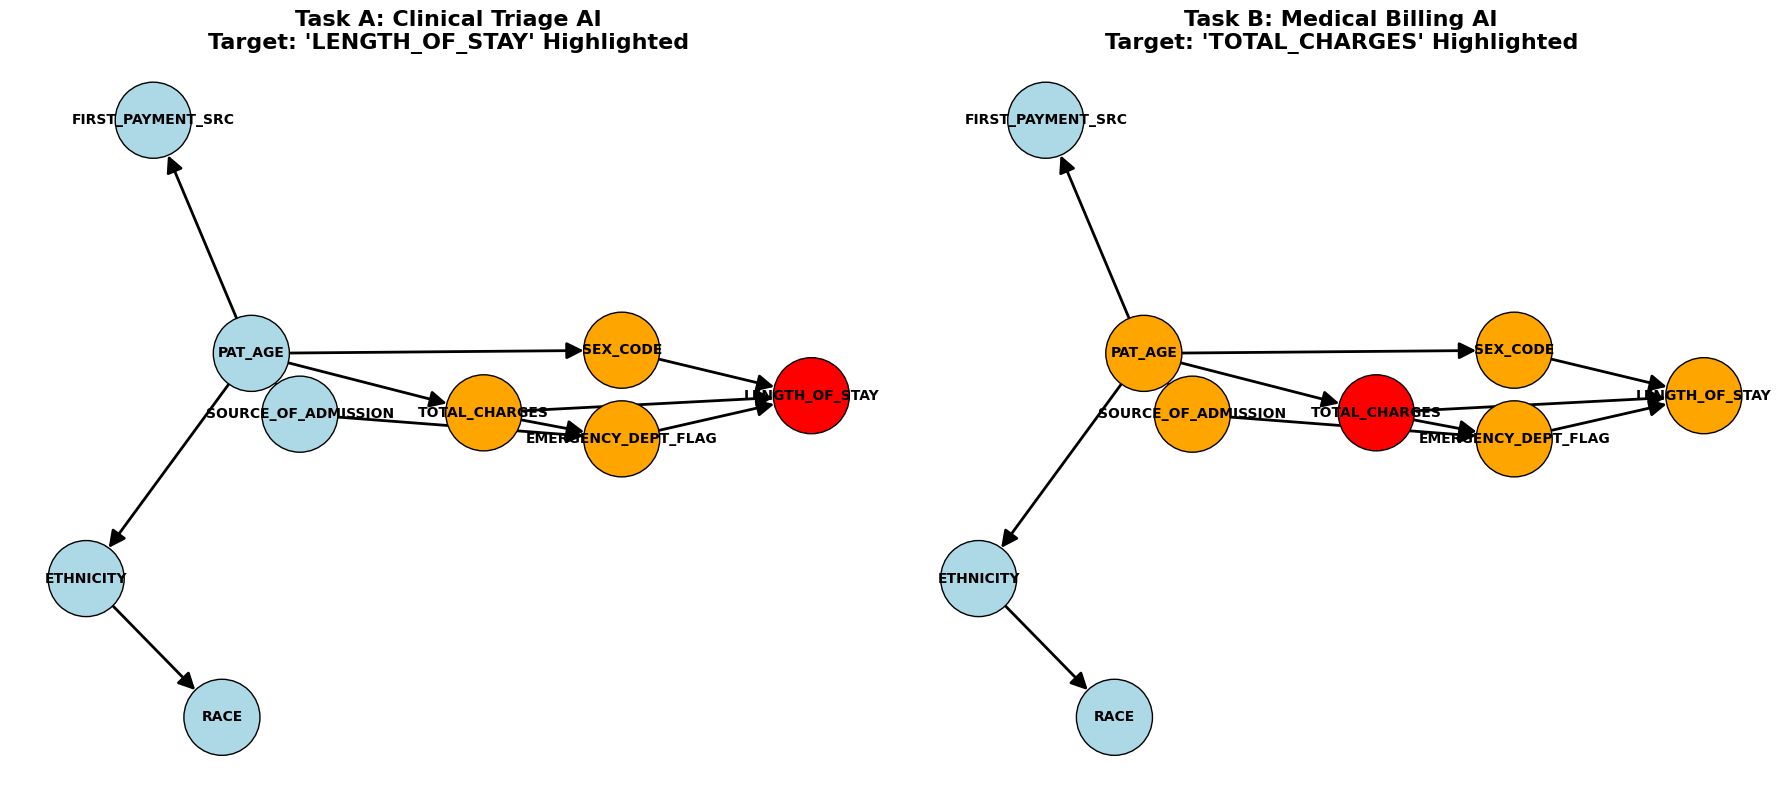

In [14]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. PREP THE DATA
# ==========================================
print("Loading the Patient Vault...")
df_vault = pd.read_csv("Cleaned_Patient_Vault.csv")
df_vault = df_vault.drop(columns=["RECORD_ID"])

print("Discretizing continuous variables...")
df_vault['TOTAL_CHARGES'] = pd.qcut(df_vault['TOTAL_CHARGES'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df_vault['LENGTH_OF_STAY'] = pd.qcut(df_vault['LENGTH_OF_STAY'], q=4, labels=['Short', 'Medium', 'Long', 'Extended'], duplicates='drop')

# Convert everything to strings so pgmpy knows it is discrete categorical data
df_vault = df_vault.astype(str)

# ==========================================
# 2. DO THE MATH (Creates 'bn')
# ==========================================
print("Running Causal Discovery (This will take a few seconds)...")
hc = HillClimbSearch(df_vault)

# FIXED: The new pgmpy 1.0 string for discrete BIC scoring is "bic-d"
best_model = hc.estimate(scoring_method="bic-d") 

bn = DiscreteBayesianNetwork(best_model.edges())

target_clinical = "LENGTH_OF_STAY"
mb_clinical = bn.get_markov_blanket(target_clinical)

target_financial = "TOTAL_CHARGES"
mb_financial = bn.get_markov_blanket(target_financial)

print(f"\nClinical AI Allowed Data: {mb_clinical}")
print(f"Billing AI Allowed Data:  {mb_financial}")

# ==========================================
# 3. DRAW THE FULL GRAPHS (WITH VISIBLE ARROWS & AIR-GAPPED DATA)
# ==========================================
print("\nGenerating full network plots with visible arrows...")
G = nx.DiGraph()
G.add_nodes_from(list(bn.nodes()))
G.add_edges_from(list(bn.edges()))

targets = {
    "Task A: Clinical Triage AI": (target_clinical, mb_clinical),
    "Task B: Medical Billing AI": (target_financial, mb_financial)
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# Let NetworkX space out the FULL graph. Seed=42 ensures left and right look identical
pos = nx.spring_layout(G, seed=42) 

for ax, (title, (target_node, mb_nodes)) in zip(axes, targets.items()):
    
    node_colors = []
    # Color logic: Red for Target, Orange for Markov Blanket, Light Blue for Air-Gapped
    for node in G.nodes():
        if node == target_node:
            node_colors.append("red")          
        elif node in mb_nodes:
            node_colors.append("orange")       
        else:
            node_colors.append("lightblue")    

    # Draw the FULL graph nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=3000, node_color=node_colors, edgecolors="black")
    
    # Draw the FULL graph edges, passing node_size so the arrows sit OUTSIDE the circles
    nx.draw_networkx_edges(
        G, pos, ax=ax, 
        arrows=True, 
        arrowstyle="-|>", 
        arrowsize=25, 
        edge_color="black", 
        width=2,
        node_size=3000  # Ensures arrows don't hide under the nodes!
    )
    
    # Add labels
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
    
    ax.axis("off")
    ax.set_title(f"{title}\nTarget: '{target_node}' Highlighted", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()